In [ ]:
%cd C:/Users/Vivek Chauhan/OneDrive/Desktop/AnalytixLabs_data_Machine/Deep_Learning

# Problem Statement : "Predict customer churn based on their demographic and account-related data, to help the bank proactively identify customers likely to leave."

# Step 1: Upload the Data 

In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv("Churn_Modelling.csv")

In [4]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Step 2: EDA

In [5]:
# Dropping Columns which do not have any predictive power

In [6]:
data = data.drop(columns = ["RowNumber", "Surname", "CustomerId"], axis = 1)

In [7]:
# Checking missing values

In [8]:
data.isna().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [9]:
# result : No missing value

In [10]:
# checking Distribution

array([[<AxesSubplot:title={'center':'CreditScore'}>,
        <AxesSubplot:title={'center':'Age'}>,
        <AxesSubplot:title={'center':'Tenure'}>],
       [<AxesSubplot:title={'center':'Balance'}>,
        <AxesSubplot:title={'center':'NumOfProducts'}>,
        <AxesSubplot:title={'center':'HasCrCard'}>],
       [<AxesSubplot:title={'center':'IsActiveMember'}>,
        <AxesSubplot:title={'center':'EstimatedSalary'}>,
        <AxesSubplot:title={'center':'Exited'}>]], dtype=object)

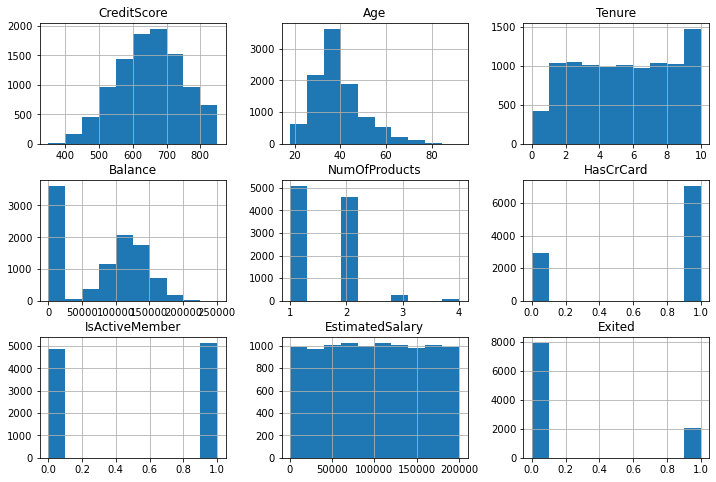

In [11]:
data.hist(figsize = (12,8))

 To address non-normal distribution in "Tenure" and "EstimatedSalary" we will do StandardScaling in later part , which will make mean = 0 and standard deviation = 1

In [12]:
# To check the outliers

<AxesSubplot:>

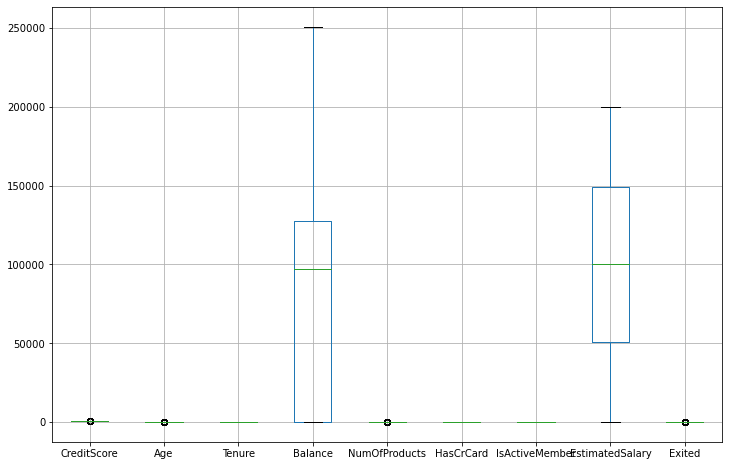

In [13]:
data.boxplot(figsize = (12,8))

In [14]:
# Result : no outliers

# Step 3: Importing relevant libraries for the ANN model 

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report, confusion_matrix

C:\Users\Vivek Chauhan\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [16]:
from sklearn.metrics import accuracy_score

In [17]:
data1= pd.get_dummies(data, drop_first = True)

In [18]:
data1.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


# Step 4: Split the Data 

In [19]:
x = data1.drop("Exited", axis = 1)

In [20]:
y = data1["Exited"]

In [21]:
print(data1.shape)
print(x.shape)

(10000, 12)
(10000, 11)


In [22]:
print(y.value_counts())

0    7963
1    2037
Name: Exited, dtype: int64


In [23]:
# Standard Scaling the data for normaly distribution

In [24]:
scaler = StandardScaler()

In [25]:
x_scaled = scaler.fit_transform(x)

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size = 0.2, random_state = 1)

# Step 5:  Addressing the class imbalance in the target variable y

In [27]:
from imblearn.over_sampling import SMOTE

In [28]:
smote = SMOTE(random_state = 42)

In [29]:
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

# Step 6: Build the ANN Model 

In [30]:
model = Sequential()

In [31]:
model.add(Dense(units = 6, activation = "relu", input_dim = x_train_res.shape[1]))

C:\Users\Vivek Chauhan\anaconda3\lib\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.add(Dense(units = 6, activation = "relu"))

In [33]:
model.add(Dense(units = 1, activation = "sigmoid")) # output layer for binary classification

# Step 7 : Compile Model 

In [34]:
model.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])

# Step 8 : Train the Model 

In [35]:
model.fit(x_train_res, y_train_res, batch_size = 32, epochs = 30, verbose = 1)

Epoch 1/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5966 - loss: 0.6626
Epoch 2/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7069 - loss: 0.5831
Epoch 3/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7267 - loss: 0.5405
Epoch 4/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7417 - loss: 0.5141
Epoch 5/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7604 - loss: 0.4935
Epoch 6/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7585 - loss: 0.4824
Epoch 7/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7755 - loss: 0.4691
Epoch 8/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7756 - loss: 0.4689
Epoch 9/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7784 - loss: 0.4632
Epoch 10/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7876 - loss: 0.4511
Epoch 11/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7815 - loss: 0.4531
Epoch 12/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

# Step 9 : Evaluate the Model 

In [36]:
y_pred = model.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [37]:
y_pred = (y_pred > 0.5).astype(int)

In [38]:
accuracy_score(y_pred,y_test)

0.801

In [39]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1391
           1       0.75      0.51      0.61       609

    accuracy                           0.80      2000
   macro avg       0.78      0.72      0.74      2000
weighted avg       0.80      0.80      0.79      2000



# Step 10 : Tuning the model for best number of neurons 

In [40]:
def create_model(neurons):
    model = Sequential()
    model.add(Dense(units=neurons, activation='relu', input_dim=x_train.shape[1]))
    model.add(Dense(units=neurons, activation='relu'))
    model.add(Dense(units=1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Try different neuron counts
neuron_options = [4, 6, 8, 10, 12, 16, 20]

for n in neuron_options:
    print(f"\n🔍 Testing model with {n} neurons per hidden layer")
    model = create_model(n)
    model.fit(x_train, y_train, epochs=40, batch_size=32, verbose=0)
    
    y_pred = (model.predict(x_test) > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ Accuracy with {n} neurons: {acc:.4f}")


🔍 Testing model with 4 neurons per hidden layer


C:\Users\Vivek Chauhan\anaconda3\lib\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
✅ Accuracy with 4 neurons: 0.8630

🔍 Testing model with 6 neurons per hidden layer


C:\Users\Vivek Chauhan\anaconda3\lib\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
✅ Accuracy with 6 neurons: 0.8655

🔍 Testing model with 8 neurons per hidden layer


...

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
✅ Accuracy with 12 neurons: 0.8635

🔍 Testing model with 16 neurons per hidden layer


C:\Users\Vivek Chauhan\anaconda3\lib\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
✅ Accuracy with 16 neurons: 0.8655

🔍 Testing model with 20 neurons per hidden layer


C:\Users\Vivek Chauhan\anaconda3\lib\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
✅ Accuracy with 20 neurons: 0.8570


In [41]:
# now you can choose your neuron value accordingly 
# I will go with n = 6 